In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
l1 = 1.0; l1c = l1 / 2;
l2 = 1.5; l2c = l2 / 2;
l3 = 0.8;
m1 = 2.0; m2 = 3.0;
d = 1;

J1 = (1/12)*m1*(l1c**2);
J2 = (1/12)*m2*(l2c**2);

In [3]:
#We define an auxiliary variable

def d_help(qI):
    
    s1, s2 = qI
    
    d_help = np.sqrt(d ** 2 + (s2 - s1) ** 2)
    
    return d_help

#Compute auxiliary angle

def gamma_au(qI):
    
    s1, s2 = qI
    y = s2 - s1
    gamma_au = np.arctan2((s2 - s1), d)
    
    return gamma_au


#Compute angles alpha and betha

def angles(qI):
    
    s1, s2 = qI
    
    d_val = d_help(qI)
    
    gamma_val = gamma_au(qI)
    
    #Compute alpha
    
    alpha = np.arccos( (l1**2 + d_val**2 - l3**2) / (2*l1*d_val) ) + gamma_val
    
    #Compute betha
    
    beta = np.arccos( (l3**2 + d_val**2 - l1**2) / (2*l3*d_val) ) - gamma_val
    
    qD = np.array([alpha,beta])
    
    return qD


In [4]:


#Mass matrix

def M_matrix(qI):
    s1, s2 = qI
    
    #Dependent variables
    qD = angles(qI)
    
    a, b = qD
    
    #Mass matrix
    
    M = np.array([
        [m1, 0, m1*l1*np.cos(a), 0],
        [0, m2, 0, m2*l2c*np.cos(b)],
        [m1*l1c*np.cos(a), 0, J1 + m1*(l1c**2), 0],
        [0, m2*l2c*np.cos(b), 0, J2 + m2*(l2c**2)]
    ])
    
    return M

In [5]:
def dependent_velocities(qI, qIdot):
    
    s1, s2 = qI
    ds1, ds2 = qIdot
    
    qD = angles(qI)
    a, b = qD
    
    alpha_dot = (ds2 -  ds1)*np.sin(b) / (l1*np.sin(a + b))
    beta_dot = (ds1 - ds2)*np.sin(a) / (l3*np.sin(a + b))
    
    qD_dot = np.array([alpha_dot, beta_dot])
    
    return qD_dot

In [6]:
def f_vector(qI, qIdot):
    s1, s2 = qI
    ds1, ds2 = qIdot
    
    #Compute dependent velocities
    
    qD = angles(qI)
    qD_dot = dependent_velocities(qI, qIdot)
    da, db = qD_dot
    a, b = qD
    
    f = np.array([
        -m1*(da**2)*l1c*np.sin(a),
        -m2*(db**2)*l2c*np.sin(b),
        0,
        0
    ])
    
    return f

In [7]:

    
B = np.array([
    [1, 0],
    [0, 1],
    [0, 0],
    [0, 0]
])
    

print(B)

#def control_input(t):
#    return np.array([1.0, 0.0])   # fuerza/torque constante

[[1 0]
 [0 1]
 [0 0]
 [0 0]]


In [8]:
def C_matrix(qI):
    
    s1, s2 = qI
    qD = angles(qI)
    a, b = qD
    
    
    C = np.array([
        [0, 1],
        [0, -1],
        [-l1*np.sin(a), l1*np.cos(a)],
        [-l3*np.sin(b), -l3*np.cos(b)]
    ])
    
    return C.T

def Q_matrix(qI,qIdot):
    
    s1, s2 = qI
    qD = angles(qI)
    qDdot = dependent_velocities(qI, qIdot)
    a, b = qD
    da, db = qDdot
    
    Q = np.array([
        l1*(da**2)*np.cos(a)+l3*(db**2)*np.cos(b),
        l1*(da**2)*np.sin(a)-l3*(db**2)*np.sin(b)
    ])

    return Q


In [9]:
GAMMA_I = np.array([
    [0, 0],
    [1, -1]
])

#Compute projection matrix.

def projection(qI,qIdot):

    qD = angles(qI)
    qDdot = dependent_velocities(qI, qIdot)
    a, b = qD
    da, db = qDdot
    
    GAMMA_D = np.array([
        [-l1*np.sin(a), -l3*np.sin(b)],
        [l1*np.cos(a), -l3*np.cos(b)]
    ])
    
    gamma = np.array([-l1*(da**2)*np.cos(a)-l3*(db**2)*np.cos(b),
                    -l1*(da**2)*np.sin(a)+l3*(db**2)*np.sin(b)])
    
    
    X = -np.linalg.solve(GAMMA_D, GAMMA_I)
    
    Jc = np.concatenate((np.eye(2),X))
    
    return Jc


In [10]:
def b_vector(qI,qIdot):
    qD = angles(qI)
    qDdot = dependent_velocities(qI, qIdot)
    a, b = qD
    da, db = qDdot
    
    GAMMA_D = np.array([
        [-l1*np.sin(a), -l3*np.sin(b)],
        [l1*np.cos(a), -l3*np.cos(b)]
    ])
    
    gamma = np.array([-l1*(da**2)*np.cos(a)-l3*(db**2)*np.cos(b),
                    -l1*(da**2)*np.sin(a)+l3*(db**2)*np.sin(b)])
    
    X = -np.linalg.solve(GAMMA_D, gamma)
    b = np.concatenate((np.array([0,0]),X))
    
    return b

    

In [22]:
# define input positions

def input_positions(t):
    
    
    x_ref = 0.5 + 0.2*np.cos(np.pi*t / 2)
    y_ref = 0.4 + 0.2*np.sin(np.pi*t / 2)
    
    s2_ref = y_ref - np.sqrt(l2**2 - (d - x_ref)**2)
    
    beta = np.arctan2((y_ref - s2_ref), (d - x_ref))
    
    s1_ref = s2_ref + l3*np.sin(beta) - np.sqrt(l1**2 -(d - l3*np.cos(beta))**2)
    
    s_ref =np.array([s1_ref, s2_ref])
    
    
    return s_ref

def input_velocities(t):
    
    h = 1e-6

    s_forward = input_positions(t + h)
    s_backward = input_positions(t - h)

    ds_ref = (s_forward - s_backward)/(2*h)
    
    return ds_ref

In [23]:
Kp=2000
Ki=0
Kd=300

qdd = []

def system(t,X):
    
    s_ref = input_positions(t)
    ds_ref = input_velocities(t)
    
    s1_ref, s2_ref = s_ref
    ds1_ref, ds2_ref = ds_ref
    
    
    qI = X[0:2]
    qIdot = X[2:4]
    xi = X[4:6]
    
    s1, s2 = qI
    ds1, ds2 = qIdot
    x1, x2 = xi
    
    e1 = s1_ref - s1
    e2 = s2_ref - s2
    
    de1 = ds1_ref - ds1
    de2 = ds2_ref - ds2
    
    u1 = Kp*e1 + Kd*de1 + Ki*x1
    u2 = Kp*e2 + Kd*de2 + Ki*x2
    
    #u1 = 0.1; u2 = 0.2;
    
    u = np.array([u1, u2])
    
    
    M = M_matrix(qI)
    f = f_vector(qI,qIdot)
    C = C_matrix(qI)
    b = b_vector(qI,qIdot)
    Q_c = Q_matrix(qI,qIdot)
    
    #ODE System
    
    M1 = np.concatenate((M,C.T),axis=1)
    M2 = np.concatenate((C,np.zeros((2,2))),axis=1)
    A = np.concatenate((M1,M2),axis = 0)
    
    
    rhs = np.concatenate((-f+B@u,Q_c),axis=0)
    v = np.linalg.solve(A, rhs)
    qIddot = v[0:2]
    
    dx1 = e1
    dx2 = e2
    
    dxi = np.array([dx1, dx2])
    
    #print("qI =", qI)
    #print("qIdot =", qIdot)
    #print("u =", u)
    #print("rhs =", rhs)
    #print("qIddot =", qIddot)
    #print("f =", f)
    #print("Qc =", Q_c)
    
    
    return np.concatenate((qIdot, qIddot, dxi))

#Initial conditions

s_0 = input_positions(0)
s_1, s_2 = s_0

X0 = np.array([s_1+0.5,s_2+0.5,0,0,0,0])

#Time

t_span = (0, 20)
t_eval = np.linspace(0, 20, 500)
    
#Simulation
    
sol=solve_ivp(system, t_span, X0, t_eval=t_eval)



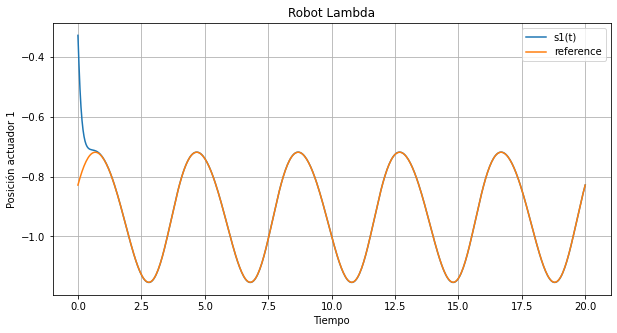

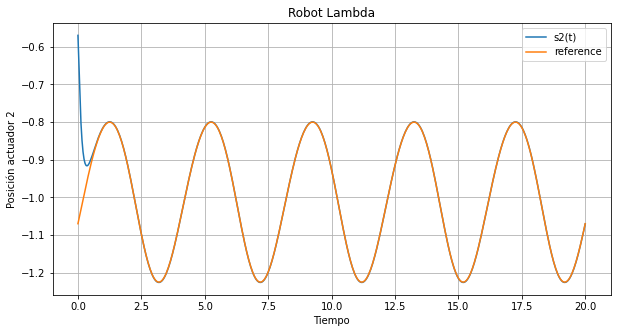

In [24]:
plt.figure(figsize=(10,5))
plt.plot(sol.t, sol.y[0], label="s1(t)")
plt.plot(sol.t, input_positions(sol.t)[0], label="reference")
plt.xlabel("Tiempo")
plt.ylabel("Posición actuador 1")
plt.title("Robot Lambda")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(sol.t, sol.y[1], label="s2(t)")
plt.plot(sol.t, input_positions(sol.t)[1], label="reference")
plt.xlabel("Tiempo")
plt.ylabel("Posición actuador 2")
plt.title("Robot Lambda")
plt.grid()
plt.legend()
plt.show()
